# RNN Beispiel
https://chatgpt.com/g/g-p-69aebe064d008191b04a8157aeaadf4e-sentiment-lstm/c/69aec479-08c0-832e-8275-1d17b4942e47

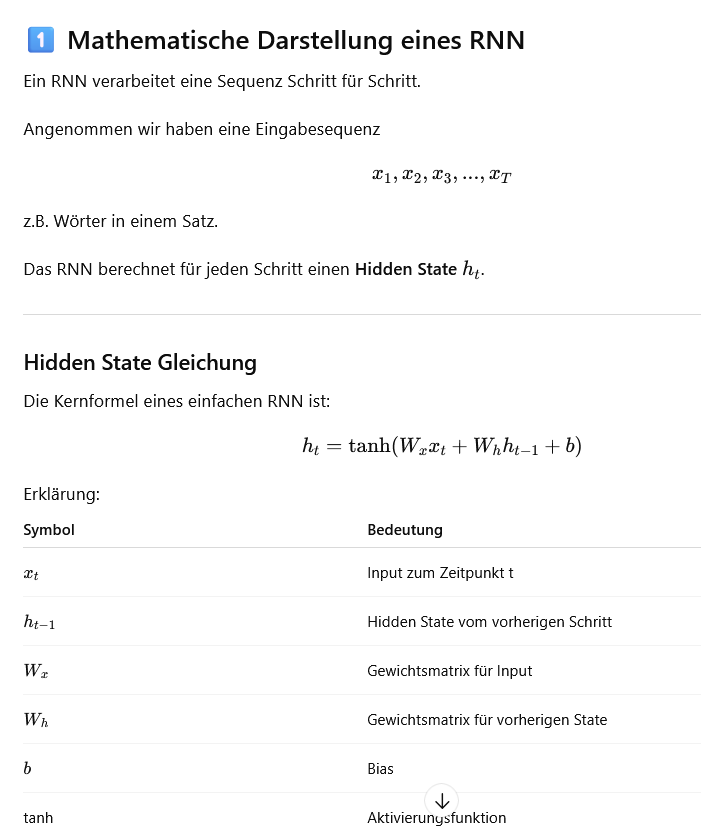

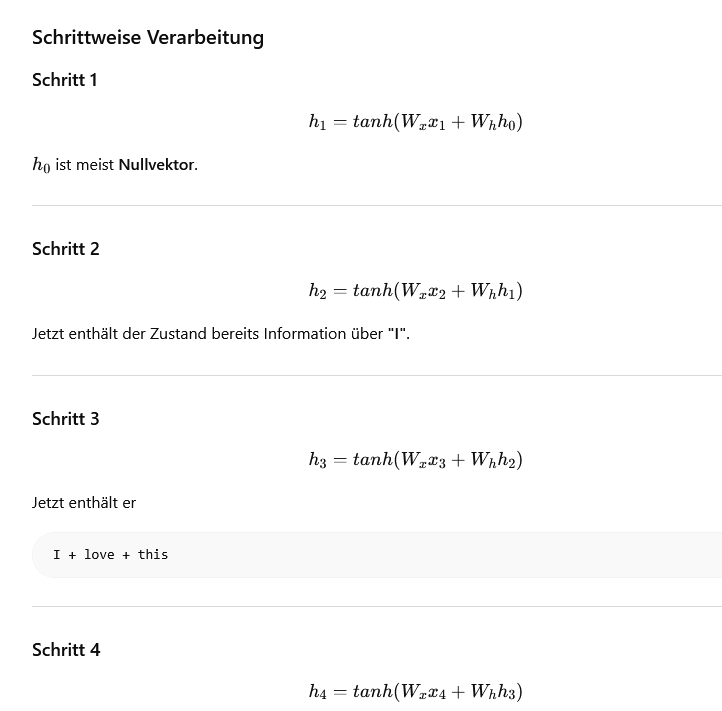

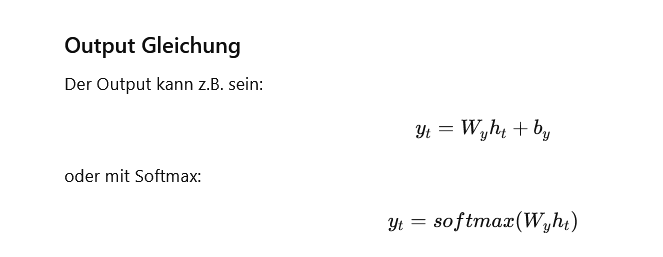

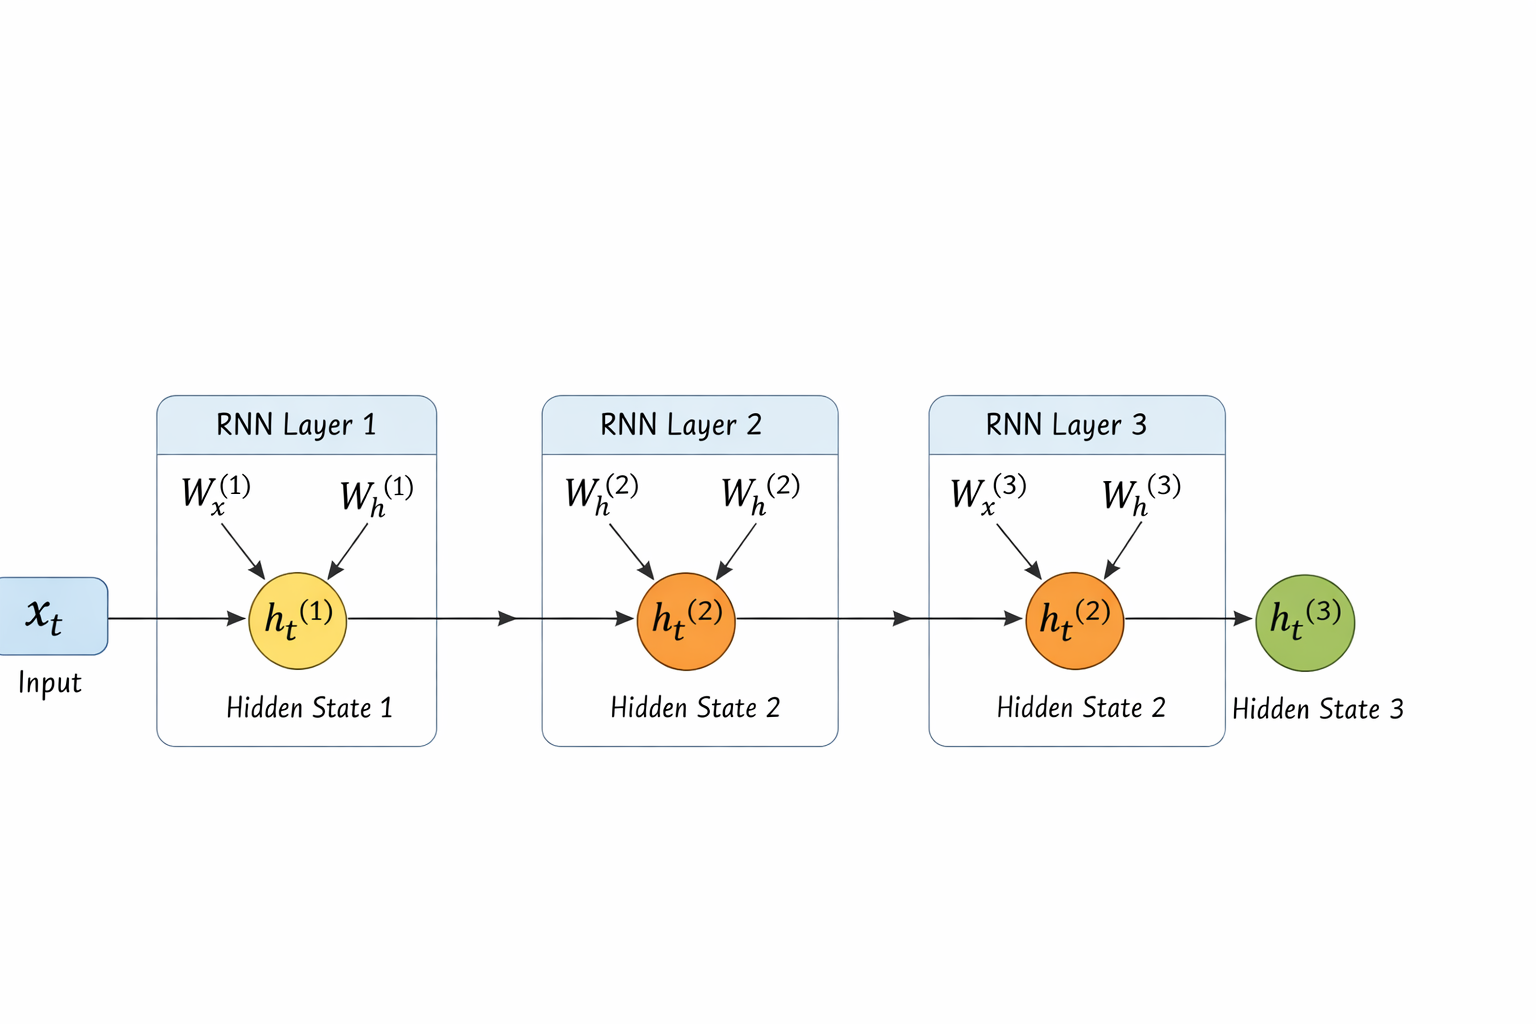


import torch
import torch.nn as nn

torch.manual_seed(0)

input_size = 3
hidden_size = 5

rnn = nn.RNN(
    input_size=input_size, #3
    hidden_size=hidden_size, #5
    num_layers=1,
    batch_first=True
)

x = torch.tensor([[
    [0.1,0.3,0.7],
    [0.9,0.2,0.4],
    [0.5,0.6,0.1],
    [0.3,0.8,0.2]
]])

Wx = rnn.weight_ih_l0
Wh = rnn.weight_hh_l0
b = rnn.bias_ih_l0 + rnn.bias_hh_l0

print("\nWx:")
print(Wx)

print("\nWh:")
print(Wh)

print("\nBias:")
print(b)

# Anfangszustand
h = torch.zeros(hidden_size)

print("\nh0:")
print(h)

outputs = []

seq_len = x.shape[1]

for t in range(seq_len):

    xt = x[0,t]

    print(f"\n===== Schritt {t+1} =====")
    print("xt:", xt)

    h = torch.tanh(
        torch.matmul(Wx, xt) +
        torch.matmul(Wh, h) +
        b
    )

    print(f"h{t+1}:", h)

    outputs.append(h)
    #print("outputs", t, outputs)

outputs = torch.stack(outputs)

print("\nAlle hidden states:")
print(outputs)

# Output layer
Wy = torch.randn(2, hidden_size)

print("\nWy:")
print(Wy)

y = torch.matmul(Wy, outputs[-1])

print("\nOutput y:")
print(y)

In [4]:
import torch
import torch.nn as nn

rnn = nn.RNN(
    input_size=3,
    hidden_size=5,
    num_layers=1,
    batch_first=True
)

x = torch.tensor([[
    [0.1,0.3,0.7],   # I
    [0.9,0.2,0.4],   # love
    [0.5,0.6,0.1],   # this
    [0.3,0.8,0.2]    # movie
]])

output, hidden = rnn(x)

print("Output:", output)
print("Hidden:", hidden)

Output: tensor([[[-0.4784,  0.5256, -0.3194,  0.5343,  0.3551],
         [-0.6483,  0.5325, -0.2773,  0.1024,  0.5445],
         [-0.7032,  0.3039, -0.3200, -0.1789,  0.2719],
         [-0.6448,  0.3419, -0.2857, -0.1040,  0.2077]]],
       grad_fn=<TransposeBackward1>)
Hidden: tensor([[[-0.6448,  0.3419, -0.2857, -0.1040,  0.2077]]],
       grad_fn=<StackBackward0>)


# RNN Layer=3

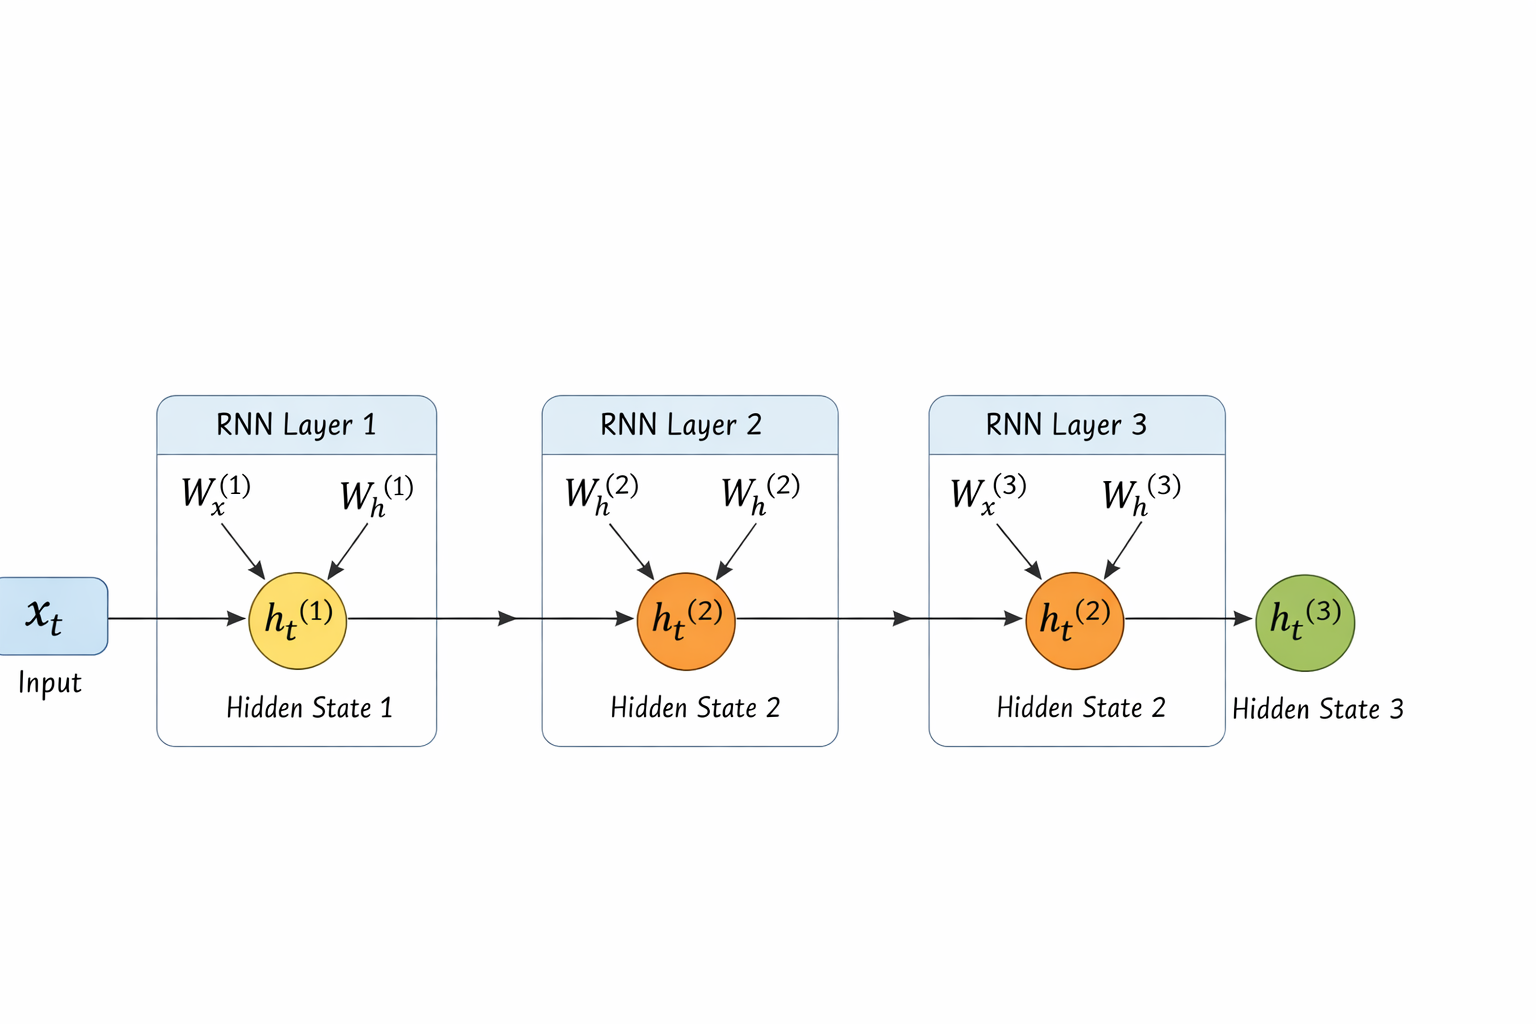

In [5]:
import torch
import torch.nn as nn

rnn = nn.RNN(
    input_size=3,
    hidden_size=5,
    num_layers=3,
    batch_first=True
)

x = torch.tensor([[
    [0.1,0.3,0.7],   # I
    [0.9,0.2,0.4],   # love
    [0.5,0.6,0.1],   # this
    [0.3,0.8,0.2]    # movie
]])

output, hidden = rnn(x)

print("Output:", output)
print("Hidden:", hidden)

Output: tensor([[[ 0.2639, -0.4716, -0.3653,  0.3366,  0.1455],
         [ 0.3925, -0.5151, -0.0858,  0.5063, -0.1860],
         [ 0.4314, -0.4856, -0.0997,  0.5215, -0.3059],
         [ 0.4456, -0.4949, -0.1163,  0.5526, -0.3200]]],
       grad_fn=<TransposeBackward1>)
Hidden: tensor([[[-0.1484, -0.7274, -0.4056, -0.6966, -0.0476]],

        [[-0.0727,  0.1161, -0.2405,  0.1647, -0.3806]],

        [[ 0.4456, -0.4949, -0.1163,  0.5526, -0.3200]]],
       grad_fn=<StackBackward0>)


# Beispiel

In [7]:
import torch
import torch.nn as nn

# Hyperparameter
batch_size = 2
seq_len = 4
input_size = 3
hidden_size = 5
num_layers = 2
num_classes = 2  # z.B. für Klassifikation

# Dummy Input (batch_first=True)
x = torch.randn(batch_size, seq_len, input_size)
print("Input x:", x)
print("x.shape:", x.shape)  # (batch, seq_len, input_size)

# RNN definieren
rnn = nn.RNN(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=True
)

# Hidden State initialisieren
h0 = torch.zeros(num_layers, batch_size, hidden_size)
print("Initial hidden state h0:", h0)
print("h0.shape:", h0.shape)

# Forward pass
out, hn = rnn(x, h0)
print("RNN output out:", out)
print("out.shape:", out.shape)  # (batch, seq_len, hidden_size)
print("Final hidden state hn:", hn)
print("hn.shape:", hn.shape)  # (num_layers, batch, hidden_size)

# Wir nehmen oft nur den letzten Zeitschritt für Klassifikation
last_time_step = out[:, -1, :]
print("Last time step:", last_time_step)
print("last_time_step.shape:", last_time_step.shape)  # (batch, hidden_size)

# Linear Layer für Klassifikation
fc = nn.Linear(hidden_size, num_classes)
logits = fc(last_time_step)
print("Logits:", logits)
print("logits.shape:", logits.shape)  # (batch, num_classes)

Input x: tensor([[[-0.1847, -0.7318, -0.0807],
         [-0.9801,  0.0605, -0.4890],
         [-1.5771,  0.3609,  1.1975],
         [-1.8345,  0.4201,  1.1290]],

        [[ 0.4264, -1.1361, -0.1292],
         [-0.0546,  0.9523, -0.4624],
         [-0.6079, -0.3625, -1.5072],
         [-0.5087, -1.2426,  1.2846]]])
x.shape: torch.Size([2, 4, 3])
Initial hidden state h0: tensor([[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]])
h0.shape: torch.Size([2, 2, 5])
RNN output out: tensor([[[-0.6140,  0.1315,  0.1215,  0.2749, -0.5861],
         [-0.6976,  0.3941,  0.0314,  0.2527, -0.6395],
         [-0.4895,  0.6788,  0.1365,  0.2570, -0.6748],
         [-0.3280,  0.7773,  0.0824,  0.3067, -0.7708]],

        [[-0.5696,  0.1135, -0.0022,  0.2703, -0.5153],
         [-0.6505,  0.3615, -0.3065,  0.2350, -0.6189],
         [-0.6861, -0.0167, -0.0642, -0.0678, -0.4078],
         [-0.4875,  0.4692,  0.2229,  0.2425, -0.2689]]],